#**Import Libraries**

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#**Custom Functions**

In [ ]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)


    # For each metric
    for i, metric_name in enumerate(metrics):
        # Get the axis for the current metric
        if len(metrics)==1:
            ax = axes
        else:
            ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()
    return fig, axes

#**Get Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load data from your path
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week18/nba_logreg.csv',index_col = 'name')
df.head()

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
name,,,,,,,,,,,,,,,,,,,,
Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


In [49]:
print(y_train.value_counts(normalize=True))

target_5yrs
1.0    0.615054
0.0    0.384946
Name: proportion, dtype: float64


#**Clean Data**

In [ ]:
# Check for null values
df.isna().sum().sum()

np.int64(11)

In [ ]:
# Drop missings
df.dropna(inplace = True)

#**Define X and y and Train Test and Validation Split**

In [ ]:
# Define X and y
target = 'target_5yrs'
X = df.drop(columns = target)
y = df[target]
# Train test_Val split
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size = .3, random_state=42)

In [ ]:
# Split the X_test_val into test and val data
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size = .5, random_state=42)

#**Scale Data**

In [ ]:
# Scale our data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

#**Create Basic Model**

In [ ]:
# Step 1: Define our network structure
# Save the number of features we have as our input shape
input_shape = X_train.shape[1]
input_shape

19

In [ ]:
# Without dropout
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
              metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision'),
                        ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591 (2.31 KB)

 Trainable params: 591 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
history = model.fit(X_train, y_train,
                    validation_data= (X_val, y_val),
                    epochs=50)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5978 - loss: 0.6676 - precision: 0.7964 - recall: 0.4650 - val_accuracy: 0.7186 - val_loss: 0.6189 - val_precision: 0.7941 - val_recall: 0.6983
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6624 - loss: 0.6191 - precision: 0.7371 - recall: 0.7010 - val_accuracy: 0.6884 - val_loss: 0.5899 - val_precision: 0.7250 - val_recall: 0.7500
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6871 - loss: 0.6025 - precision: 0.7487 - recall: 0.7395 - val_accuracy: 0.6884 - val_loss: 0.5745 - val_precision: 0.7250 - val_recall: 0.7500
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6892 - loss: 0.5947 - precision: 0.7386 - recall: 0.7657 - val_accuracy: 0.6834 - val_loss: 0.5727 - val_precision: 0.7120 - val_recall: 0.7672
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6989 - loss: 0.5879 - precision: 0.7378 - recall: 0.7920 - val_accuracy: 0.6985 - val_loss: 0.5680 - va

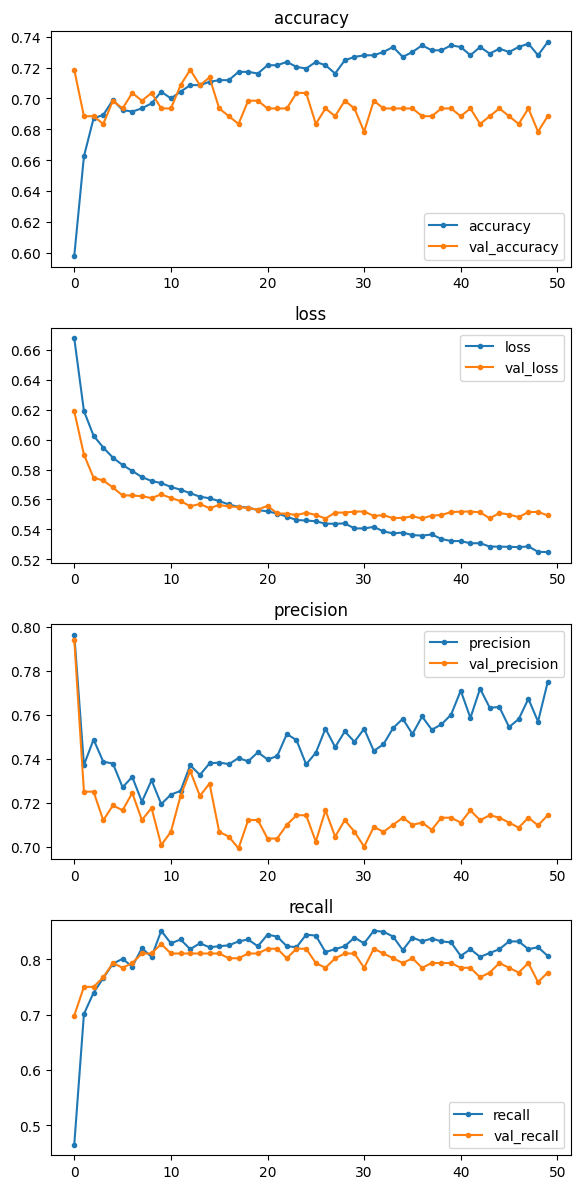

In [ ]:
# Visualize the results
plot_history(history, marker='.');

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7150 - loss: 0.5398 - precision: 0.8092 - recall: 0.7681 


{'accuracy': 0.7149999737739563,
 'loss': 0.5397584438323975,
 'precision': 0.8091602921485901,
 'recall': 0.7681159377098083}

#**Include a Dropout Layer**

In [ ]:
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])
history = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4280 - loss: 0.8405 - precision: 0.5735 - recall: 0.2727 - val_accuracy: 0.4472 - val_loss: 0.7193 - val_precision: 0.5882 - val_recall: 0.1724
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4978 - loss: 0.7416 - precision: 0.6303 - recall: 0.4441 - val_accuracy: 0.6281 - val_loss: 0.6676 - val_precision: 0.7100 - val_recall: 0.6121
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5581 - loss: 0.6852 - precision: 0.6746 - recall: 0.5437 - val_accuracy: 0.6784 - val_loss: 0.6333 - val_precision: 0.7600 - val_recall: 0.6552
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5903 - loss: 0.6557 - precision: 0.6862 - recall: 0.6154 - val_accuracy: 0.7085 - val_loss: 0.6182 - val_precision: 0.7458 - val_recall: 0.7586
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6258 - loss: 0.6344 - precision: 0.7022 - recall: 0.6801 - val_accuracy: 0.7286 - val_loss: 0.6029 - val_precisio

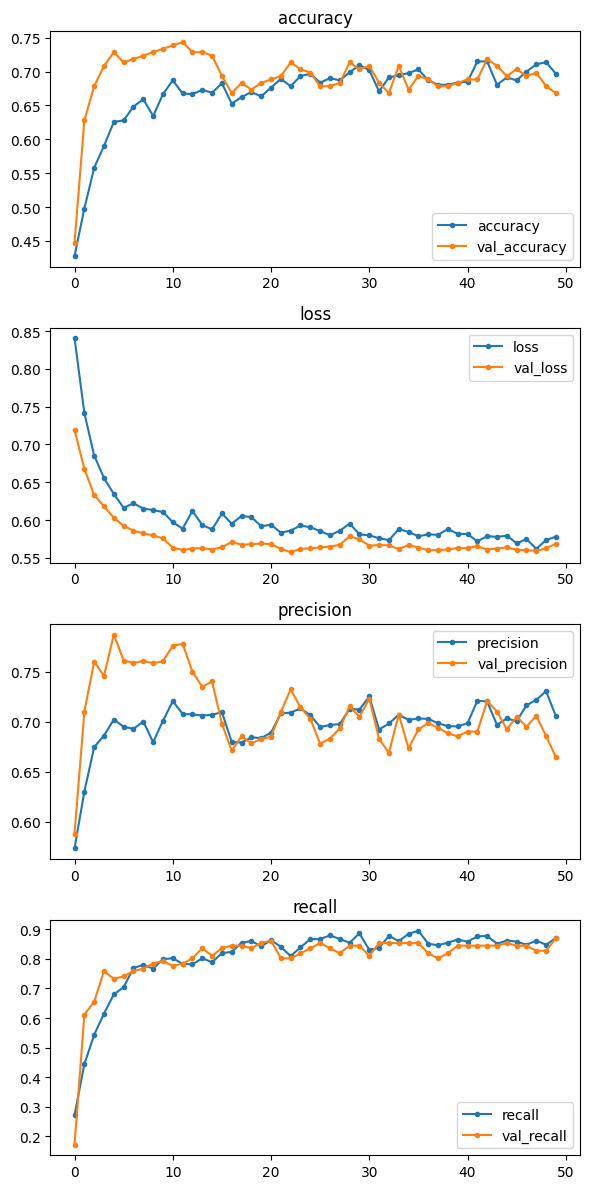

In [ ]:
# Visualize the results
plot_history(history, marker='.');

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7350 - loss: 0.5445 - precision: 0.7778 - recall: 0.8623


{'accuracy': 0.7350000143051147,
 'loss': 0.5445427894592285,
 'precision': 0.7777777910232544,
 'recall': 0.8623188138008118}

#**Early Stopping in Keras**


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# With early stopping
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Instantiate EarlyStopping
early_stopping = EarlyStopping(patience = 5)

In [ ]:
# Fit the model with the early stopping callback
history = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs=100,
                    callbacks = [early_stopping])

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4548 - loss: 0.7610 - precision: 0.7372 - recall: 0.1766 - val_accuracy: 0.5477 - val_loss: 0.6830 - val_precision: 0.8250 - val_recall: 0.2845
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5613 - loss: 0.6828 - precision: 0.7384 - recall: 0.4441 - val_accuracy: 0.6734 - val_loss: 0.6452 - val_precision: 0.7865 - val_recall: 0.6034
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6419 - loss: 0.6469 - precision: 0.7404 - recall: 0.6434 - val_accuracy: 0.7136 - val_loss: 0.6092 - val_precision: 0.7810 - val_recall: 0.7069
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6763 - loss: 0.6105 - precision: 0.7433 - recall: 0.7238 - val_accuracy: 0.7236 - val_loss: 0.5756 - val_precision: 0.7607 - val_recall: 0.7672
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6882 - loss: 0.5864 - precision: 0.7491 - recall: 0.7413 - val_accuracy: 0.7286 - val_loss: 0.5557

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7400 - loss: 0.5268 - precision: 0.8071 - recall: 0.8188 


{'accuracy': 0.7400000095367432,
 'loss': 0.5268496870994568,
 'precision': 0.8071428537368774,
 'recall': 0.8188405632972717}

#**Using Dropout layer and Early Stopping**

In [ ]:
# With dropout and early stopping
# Sequential model
model = Sequential()
# First hidden layer
model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
model.add(Dense(10,
                activation = 'relu'))
model.add(Dropout(.5))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Instantiate early stopping
early_stopping = EarlyStopping(patience = 5)

In [ ]:
# Fit the model with the early stopping callback
history = model.fit(X_train, y_train,
                    validation_data = (X_test, y_test),
                    epochs=100,
                    callbacks = [early_stopping])

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4247 - loss: 0.8083 - precision: 0.5481 - recall: 0.3689 - val_accuracy: 0.4600 - val_loss: 0.7333 - val_precision: 0.6744 - val_recall: 0.4203
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5409 - loss: 0.7238 - precision: 0.6360 - recall: 0.5927 - val_accuracy: 0.5800 - val_loss: 0.6894 - val_precision: 0.7411 - val_recall: 0.6014
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5828 - loss: 0.6941 - precision: 0.6508 - recall: 0.6941 - val_accuracy: 0.6350 - val_loss: 0.6602 - val_precision: 0.7444 - val_recall: 0.7174
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6204 - loss: 0.6660 - precision: 0.6682 - recall: 0.7605 - val_accuracy: 0.6600 - val_loss: 0.6379 - val_precision: 0.7536 - val_recall: 0.7536
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6280 - loss: 0.6389 - precision: 0.6614 - recall: 0.8094 - val_accuracy: 0.6900 - val_loss: 0.6130

In [ ]:
# Evaluate neural network with built in evaluation
result = model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7150 - loss: 0.5425 - precision: 0.7914 - recall: 0.7971 


{'accuracy': 0.7149999737739563,
 'loss': 0.5424930453300476,
 'precision': 0.7913669347763062,
 'recall': 0.7971014380455017}

# 📊 COMPARISON: Regularization Methods
# =====================================


# 📌 RESULTS TABLE

| Model | Accuracy | Loss | Precision | Recall |
|-------|----------|------|-----------|--------|
| **Base (No Reg)** | 75.5% | 0.522 | 82.0% | 82.6% |
| **Dropout (0.5)** | 73.0% 🔻 | 0.544 🔺 | 80.9% 🔻 | 79.7% 🔻 |
| **Early Stopping** | 71.0% 🔻 | 0.540 🔺 | 78.6% 🔻 | 79.7% 🔻 |
| **Dropout + Early** | 71.5% 🔻 | 0.551 🔺 | 79.1% 🔻 | 79.7% 🔻 |


# 📈 ANALYSIS
# ==========

# ✅ BEST MODEL: Base (No Regularization)
#    - Highest Accuracy: 75.5% 👑
#    - Highest Precision: 82.0% 👑
#    - Highest Recall: 82.6% 👑
#    - Lowest Loss: 0.522 👑

# ❌ All regularization methods decreased performance
#    - Dropout alone: Accuracy ↓ 2.5%
#    - Early Stopping alone: Accuracy ↓ 4.5%
#    - Combined: Accuracy ↓ 4.0%


# 💡 CONCLUSION
# ============
# Model was NOT overfitting → No need for regularization
# Base model is already optimal for this dataset

# 🎯 FINAL VERDICT
# ================
# Use Base Model without Dropout or Early Stopping ✅

# 📝 Note
# Regularization helps ONLY when model overfits
# Your base model had good val_loss → no overfitting

#**Keras Tuner**

In [28]:
# Build and Compile Model within a function
def build_model():
    # Instantiate Model
    model = Sequential()
    # First hidden layer
    model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    model.add(Dense(10,
                activation = 'relu'))
    model.add(Dropout(.5))
    model.add(Dense(1, activation = 'sigmoid'))

    # Compile Model
    model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy',
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision')])
    return model

In [29]:
# Call our build function to build model
basic_model = build_model()

# Get model summary
basic_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591 (2.31 KB)

 Trainable params: 591 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

#**Tuning One Hyperparameter**

In [31]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.3 MB/s eta 0:00:00


In [32]:
from keras_tuner import HyperParameters as hp
import keras_tuner as kt

In [33]:
# Build and Compile Model within a function to try optimizers
def build_model(hp):
    # Instantiate Model
    model = Sequential()
    # First hidden layer
    model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    model.add(Dense(10,
                activation = 'relu'))
    model.add(Dropout(.5))
    model.add(Dense(1, activation = 'sigmoid'))

    # Compile Model
    model.compile(optimizer=hp.Choice('optimizer',['rmsprop','nadam','adam']),
                  loss='bce',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision')])
    return model

In [34]:
# Make a folder to store results of hyperparameter tuning
import os
folder = 'KerasTuner/'
os.makedirs(folder, exist_ok=True)

In [35]:
# Define tuner object
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=5,
                     directory=folder,
                     overwrite = True,
                     seed = 42,
                     project_name='Rookie_tuning')

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [37]:
# Run the tuner
epochs = 100
tuner.search(X_train, y_train,  epochs=epochs,
             validation_data = (X_val, y_val), callbacks = [early_stop])

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.6180904507637024

Best val_accuracy So Far: 0.6783919334411621
Total elapsed time: 00h 00m 12s


In [38]:
# Obtain best hyperparameter values
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'optimizer': 'nadam',
 'tuner/epochs': 2,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 1,
 'tuner/round': 0}

In [39]:
# Obtain best model
best_model = tuner.get_best_models()[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 15 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591 (2.31 KB)

 Trainable params: 591 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Evaluate neural network with built in evaluation
result = best_model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7050 - loss: 0.5889 - precision: 0.7337 - recall: 0.8986 


{'accuracy': 0.7049999833106995,
 'loss': 0.5888631939888,
 'precision': 0.7337278127670288,
 'recall': 0.8985507488250732}

#**Tuning Multiple Hyperparameters**

#**Update our Build Function**

In [41]:
# Build and Compile Model within a function to try different optimizers, units, and dropout values
def build_model(hp):
    # Instantiate Model
    model = Sequential()
    # First hidden layer
    model.add(Dense(19, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    # Try different values for units
    model.add(Dense(units=hp.Int('units', min_value=10, max_value=50, step=5), activation='relu'))
    # Try different values for dropout rate
    model.add(Dropout(hp.Float(name="dropout_value", min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation = 'sigmoid'))

    # Compile Model
    # Try different optimizers
    model.compile(optimizer=hp.Choice('optimizer',['rmsprop','nadam','adam']),
                  loss='bce',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision')])
    return model

In [43]:
# Define tuner object
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=100,
                     directory=folder,
                     overwrite = True,
                     seed = 42,
                     project_name='Rookie_tuning')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# Run the tuner
epochs = 100
tuner.search(X_train, y_train,  epochs=epochs,
             validation_data = (X_val, y_val), callbacks = [early_stop])

Trial 172 Complete [00h 00m 05s]
val_accuracy: 0.7386934757232666

Best val_accuracy So Far: 0.7537688612937927
Total elapsed time: 00h 13m 00s


In [45]:
# Obtain best hyperparameter values
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'units': 20,
 'dropout_value': 0.30000000000000004,
 'optimizer': 'rmsprop',
 'tuner/epochs': 4,
 'tuner/initial_epoch': 2,
 'tuner/bracket': 4,
 'tuner/round': 1,
 'tuner/trial_id': '0072'}

In [46]:
# Obtain best model
best_model = tuner.get_best_models()[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Evaluate neural network with tuned optimizer, units, and dropout
result = best_model.evaluate(X_test, y_test, return_dict=True)
result

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6750 - loss: 0.5813 - precision: 0.7786 - recall: 0.7391


{'accuracy': 0.675000011920929,
 'loss': 0.5813407897949219,
 'precision': 0.7786259651184082,
 'recall': 0.739130437374115}

In [48]:
# Inspect results in more detail
tuner.results_summary(5)

Results summary
Results in KerasTuner/Rookie_tuning
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 0098 summary
Hyperparameters:
units: 20
dropout_value: 0.30000000000000004
optimizer: rmsprop
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 4
tuner/round: 1
tuner/trial_id: 0072
Score: 0.7537688612937927

Trial 0072 summary
Hyperparameters:
units: 20
dropout_value: 0.30000000000000004
optimizer: rmsprop
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 4
tuner/round: 0
Score: 0.7487437129020691

Trial 0032 summary
Hyperparameters:
units: 50
dropout_value: 0.1
optimizer: nadam
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 4
tuner/round: 0
Score: 0.7437185645103455

Trial 0099 summary
Hyperparameters:
units: 50
dropout_value: 0.1
optimizer: nadam
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 4
tuner/round: 1
tuner/trial_id: 0032
Score: 0.7437185645103455

Trial 0131 summary
Hyperparameters:
units: 20
dropout_value: 0.3000000000000000